<a href="https://colab.research.google.com/github/travinn44/Term-Project2/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [ ]:
#Please write the code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from google.colab import files
uploaded = files.upload()
# Load data (ensure the CSV is in the same folder as this notebook)
data = pd.read_csv('car_purchase_data.csv')
display(data.head())
print('Shape:', data.shape)


Saving car_purchase_data.csv to car_purchase_data.csv


,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


Shape: (400, 5)


### Step 2: Split features and target

In [ ]:
#Please write the code here
# Features and target
X = data[['Age', 'Salary']]
y = data['Purchased']

print('X shape:', X.shape)
print('y distribution:\n', y.value_counts())


X shape: (400, 2)
y distribution:
 Purchased
0    257
1    143
Name: count, dtype: int64


### Step 3: Train/Test Split

In [ ]:
#Please write the code here
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)
print('Train size:', X_train.shape[0], ' Test size:', X_test.shape[0])


Train size: 300  Test size: 100


### Step 4: Feature Scaling

In [ ]:
#Please write the code here
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print('Scaling complete.')


Scaling complete.


### Step 5: Train Logistic Regression Model

In [ ]:
#Please write the code here
model = LogisticRegression()
model.fit(X_train, y_train)
print('Model trained.')

Model trained.


### Step 6: Predict and Evaluate

In [ ]:
#Please write the code here
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print('Accuracy:', acc)
print('\nConfusion Matrix:\n', cm)
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.89

Confusion Matrix:
 [[65  3]
 [ 8 24]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100



### Step 7: Visualization of Decision Regions

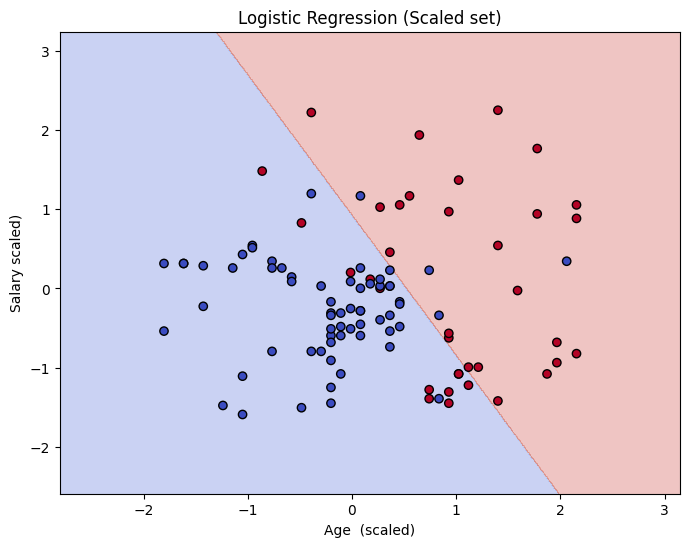

In [ ]:
#Please write the code here
import numpy as np
import matplotlib.pyplot as plt

X_set, y_set = X_test[:, :2], y_test.values
model_2d = LogisticRegression(max_iter=1000)
model_2d.fit(X_train[:, :2], y_train)

x1_min, x1_max = X_set[:, 0].min() - 1, X_set[:, 0].max() + 1
x2_min, x2_max = X_set[:, 1].min() - 1, X_set[:, 1].max() + 1
X1, X2 = np.meshgrid(
    np.arange(start=x1_min, stop=x1_max, step=0.01),
    np.arange(start=x2_min, stop=x2_max, step=0.01)
)

Z = model_2d.predict(np.array([X1.ravel(), X2.ravel()]).T)
Z = Z.reshape(X1.shape)

plt.figure(figsize=(8,6))
plt.contourf(X1, X2, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, edgecolor='k', cmap='coolwarm')
plt.title('Logistic Regression (Scaled set)')
plt.xlabel('Age  (scaled)')
plt.ylabel('Salary scaled)')
plt.show()


## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


#Please write your answer here



1.   it can be used for classifcication by applying a threshold to its output. usually this threshold is at .50 meaning that anything above .50 is classifieda as 1 and anything below is classified as 0 which is useful in mapping probability on if an event is going to occur.  

2.   based on my model people that are older with higher salaries are predicted to buy a car more often than younger people with lower salaries.

3. Some Factors that might lower the accuracy in this task would be outliers, improper scaling or an imbalanced dataset. these give the model extra data to track of poor quality which can lead to hallucionations and poor results.  

4. We can add new features that might play into a person purchasing a vehicle as age and salary only captures part of the story. balancing the dataset and removing outliers would help boost the accuracy of our model.

